Tyler Beaulieu  
DS5010, Fall 2024   
October 10, 2024  

<h4 style="text-align:center;">Homework 4</h4>

In [62]:
import numpy as np
import pandas as pd

<div class="alert alert-block alert-info">
    <b><p style="font-size: XX-large">Problem 1: Creating Data Series and DataFrame</p></b> </div>


Use the functions in the lecture notes or mentioned in hints. **Each step in problem 1 should have no more than three lines of code.**

1. (4 pt) Create a List containing 5 string objects.\
For example: string_list = ["String1", "String2", "String3", "String4", "String5"]\
Convert the list to a Data Series object. 

In [63]:
string_theory = ["This is a string", "This is also a string", "Yet another string", "Hey look, more strings", "wow, string, wow"]
string_theory = pd.Series(string_theory)
string_theory

0          This is a string
1     This is also a string
2        Yet another string
3    Hey look, more strings
4          wow, string, wow
dtype: object

2. (4 pt) Create a numpy array containing 5 random integers ranging from 0 and 100 inclusively and convert it to a Data Series object. 

In [64]:
rando_array = np.random.randint(0,100,5)
rando_array = pd.Series(rando_array)
rando_array

0    61
1    52
2    69
3    64
4    48
dtype: int32

3. (4 pt) Create a dictionary containing 5 items whose keys needs to match the 5 strings from step 1.  \
For example: data_dict = {"String1": 10, "String2": 25, "String3": 15, "String4": 30, "String5": 20} \
Convert the resulting dictionary to a Data Series object. 

In [65]:
data_dict = {"This is a string":10, "This is also a string":25, "Yet another string":15, "Hey look, more strings":30, "wow, string, wow":20}
data_dict = pd.Series(data_dict)
data_dict

This is a string          10
This is also a string     25
Yet another string        15
Hey look, more strings    30
wow, string, wow          20
dtype: int64

4. (8 pt) Combine the Data Series objects from question 1, 2, and 3 to produce a Data Frame object.
Please print the output.\
Must use [reset_index()](https://www.w3schools.com/python/pandas/ref_df_reset_index.asp) function for this step for full mark. It resets the index of the DataSeries object and uses the default one instead. Might be helpful to use the help() on reset_index() to view some of the parameters it offers.

In [66]:
data_reset = data_dict.reset_index().rename(columns={"index":"Some strings",0:"More Integers"})
data_merge = pd.DataFrame({"Strings":string_theory,"Integers":rando_array})
df = pd.merge(data_reset, data_merge, left_index=True, right_index=True)
df

,Some strings,More Integers,Strings,Integers
0,This is a string,10,This is a string,61
1,This is also a string,25,This is also a string,52
2,Yet another string,15,Yet another string,69
3,"Hey look, more strings",30,"Hey look, more strings",64
4,"wow, string, wow",20,"wow, string, wow",48


---

<div class="alert alert-block alert-info">
    <b><p style="font-size: XX-large">Problem 2: Grades</p></b> </div>



Use the functions in the lecture notes or mentioned in hints. **Each questions in problem 2 should have no more than three lines of code.**

1.(2 pt) Create a Data Frame object that looks like the following:\
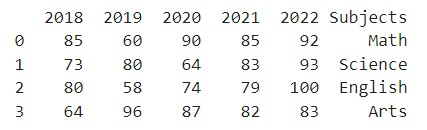\

In [67]:
df = pd.DataFrame({2018:[85,73,80,64],
                   2019:[60,80,58,96],
                   2020:[90,64,74,87],
                   2021:[85,83,79,82],
                   2022:[92,93,100,83],
                   "Subjects":["Math","Science","English","Arts"]})
df

,2018,2019,2020,2021,2022,Subjects
0,85,60,90,85,92,Math
1,73,80,64,83,93,Science
2,80,58,74,79,100,English
3,64,96,87,82,83,Arts


2.(2 pt) Set Subjects as the index. 

In [68]:
df = df.set_index("Subjects")
df

,2018,2019,2020,2021,2022
Subjects,,,,,
Math,85,60,90,85,92
Science,73,80,64,83,93
English,80,58,74,79,100
Arts,64,96,87,82,83


3.(4 pt) Use Selection by Label to select grades for Subject Math and English and print\

In [69]:
print(df.loc[['Math','English']])

          2018  2019  2020  2021  2022
Subjects                              
Math        85    60    90    85    92
English     80    58    74    79   100



4.(4 pt) Use Selection by Label and slice object to select Subjects Math through English inclusively between the years 2019-2021 also inclusively and print.\

In [70]:
print(df.loc['Math':'English',2019:2021])

          2019  2020  2021
Subjects                  
Math        60    90    85
Science     80    64    83
English     58    74    79


5.(4 pt) Use Selection by Position to select grades for Subject Math and English and print\

In [71]:
print(df.iloc[[0,2]])

          2018  2019  2020  2021  2022
Subjects                              
Math        85    60    90    85    92
English     80    58    74    79   100


6.(4 pt) Use Selection by Position and slice object to select Subjects Math through English inclusively between the years 2019-2021 also inclusively and print. 

In [72]:
print(df.iloc[0:3,1:4])

          2019  2020  2021
Subjects                  
Math        60    90    85
Science     80    64    83
English     58    74    79


---

<div class="alert alert-block alert-info">
    <b><p style="font-size: XX-large">Problem 3: Manipulating DataFram</p></b> </div>


Mind that each question uses result from the previous question. Using the resulting dataframe from Problem 2 Question 2, do the following:

1.(4 pt) Use slicer object to give every single subject in year 2019 a +3 grade bump and print the resulting DataFrame.\

In [73]:
df.loc[:,2019] += 3
df

,2018,2019,2020,2021,2022
Subjects,,,,,
Math,85,63,90,85,92
Science,73,83,64,83,93
English,80,61,74,79,100
Arts,64,99,87,82,83


2.(4 pt) Change the grade on Math in Year 2021 to 95 and print the resulting DataFrame.\

In [74]:
df.loc["Math",2021] = 95
df

,2018,2019,2020,2021,2022
Subjects,,,,,
Math,85,63,90,95,92
Science,73,83,64,83,93
English,80,61,74,79,100
Arts,64,99,87,82,83


3.(6 pt) Add another column to the DataFrame object to denote the mean across all years. [mean()](https://www.w3schools.com/python/ref_stat_mean.asp) function returns the average of the data and sort the rows (Subjects) by ascending order alphabetically.\

In [75]:
df["Mean"] = df.mean(axis=1)
df = df.sort_index()
df

,2018,2019,2020,2021,2022,Mean
Subjects,,,,,,
Arts,64,99,87,82,83,83.0
English,80,61,74,79,100,78.8
Math,85,63,90,95,92,85.0
Science,73,83,64,83,93,79.2


4.(2 pt) Print the lowest grade in 2020.\

In [76]:
df[2020].min()

64

5.(2 pt) Drop both Science and Arts and print the resulting DataFrame.\

In [77]:
df = df.drop(["Science", "Arts"])
df

,2018,2019,2020,2021,2022,Mean
Subjects,,,,,,
English,80,61,74,79,100,78.8
Math,85,63,90,95,92,85.0


6.(2 pt) Drop both year 2021 and print the resulting DataFrame.

In [78]:
df.drop(2021, axis=1, inplace = True)
df

,2018,2019,2020,2022,Mean
Subjects,,,,,
English,80,61,74,100,78.8
Math,85,63,90,92,85.0


----

<div class="alert alert-block alert-info">
    <b><p style="font-size: XX-large">Problem 4: CSV Data Analysis I</p></b> </div>


1.(3 pt) Read from the attached IrisData.csv and print out the first 10 and the last 10 lines. For full remarks, must use the [head()](https://www.w3schools.com/python/pandas/ref_df_head.asp) and the [tail()](https://www.w3schools.com/python/pandas/ref_df_tail.asp) function which allows users to view the first x number and last x number of lines from the DataFrame.\

In [79]:
#flights = pd.read_csv('Files/flights.csv')
iris = pd.read_csv('Files/IrisData.csv')
print(iris.head(10))
print(iris.tail(10))

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
5           5.4          3.9           1.7          0.4  setosa
6           4.6          3.4           1.4          0.3  setosa
7           5.0          3.4           1.5          0.2  setosa
8           4.4          2.9           1.4          0.2  setosa
9           4.9          3.1           1.5          0.1  setosa
     sepal_length  sepal_width  petal_length  petal_width    species
140           6.7          3.1           5.6          2.4  virginica
141           6.9          3.1           5.1          2.3  virginica
142           5.8          2.7           5.1          1.9  virginica
143           6.8   

2.(3 pt) Use [info()](https://www.w3schools.com/python/pandas/ref_df_info.asp) function to get a glance at some information about the dataset, such as the class of the object, # number of rows and columns and column data types. Use [describe()](https://www.w3schools.com/python/pandas/ref_df_describe.asp) function to get a glance at the statistical metrics about the dataset.\

In [80]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  147 non-null    float64
 1   sepal_width   147 non-null    float64
 2   petal_length  148 non-null    float64
 3   petal_width   148 non-null    float64
 4   species       147 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [81]:
iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,147.000000,147.000000,148.000000,148.000000
mean,5.851701,3.051701,3.766892,1.194595
std,0.829702,0.435788,1.766868,0.767431
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.575000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


3.(10 pt) As you can probably see from the head() and the tail() output, there are rows with some values as null or NaN. Use [isnull()](https://www.w3schools.com/python/pandas/ref_df_isnull.asp) function to mask all missing values to true. Then use [any()](https://www.w3schools.com/python/ref_func_any.asp) function to filter out which entries have missing values. Lastly use the resulting boolean mask to select all the rows with at least one value missing.\

In [82]:
iris_filter = iris.isnull()
for row in iris_filter.index:
    if any(iris_filter.loc[row]) == True:
        iris_filter.loc[row] = True
iris[iris_filter == True].dropna(thresh=4)

,sepal_length,sepal_width,petal_length,petal_width,species
14,5.8,4.0,1.2,0.2,NaN
23,5.1,3.3,NaN,0.5,setosa
37,NaN,3.1,1.5,0.1,setosa
58,6.6,2.9,NaN,1.3,versicolor
64,5.6,2.9,3.6,1.3,NaN
83,6.0,2.7,5.1,NaN,versicolor
100,NaN,3.3,6.0,2.5,virginica
122,7.7,NaN,6.7,2.0,virginica
147,6.5,3.0,5.2,2.0,NaN


4.(4 pt) Drop all entries with missing values, and print out the resulting row count. Note that [len()](https://www.w3schools.com/python/ref_func_len.asp) gives the number of items in an object.

In [83]:
iris = iris.dropna()
print(len(iris),"rows")

139 rows


----

<div class="alert alert-block alert-info">
    <b><p style="font-size: XX-large">Problem Set 5: CSV Data Analysis II</p></b> </div>


Continued this problem with the Data Frame object produced at the end of Problem Set 4.\

1.(4 pt) Use [value_counts()](https://www.w3resource.com/pandas/series/series-value_counts.php) to determine which species shows up more frequently.\

In [84]:
iris['species'].value_counts()

species
virginica     47
setosa        46
versicolor    46
Name: count, dtype: int64

2.(4 pt) Is there duplicated data in this DataFrame? Must use [duplicated()](https://www.w3schools.com/python/pandas/ref_df_duplicated.asp) function to show. Print duplicated rows.\

In [85]:
iris[iris.duplicated()]

,sepal_length,sepal_width,petal_length,petal_width,species
34,4.9,3.1,1.5,0.1,setosa
142,5.8,2.7,5.1,1.9,virginica


3.(4 pt) Filter data only have sepal_length greater than 5 sepal_width greater than 3\

In [88]:
iris.loc[(iris['sepal_length'] > 5) & (iris['sepal_width'] > 3)]

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
10,5.4,3.7,1.5,0.2,setosa
15,5.7,4.4,1.5,0.4,setosa
16,5.4,3.9,1.3,0.4,setosa
18,5.7,3.8,1.7,0.3,setosa
19,5.1,3.8,1.5,0.3,setosa
20,5.4,3.4,1.7,0.2,setosa
21,5.1,3.7,1.5,0.4,setosa
27,5.2,3.5,1.5,0.2,setosa


4.(4 pt) Use [idxmax()](https://www.w3schools.com/python/pandas/ref_df_idxmax.asp) to determine the index with the highest of each column value. For example for sepal_length it should be 131.\

In [89]:
iris.idxmax()

sepal_length    131
sepal_width      15
petal_length    118
petal_width     109
species         101
dtype: int64

5.(4 pt) Use only the column with numeric value types to contruct a convariance and correlation matrix. Which column other than itself is most correlated to sepal_length. Hint - [cov()](https://www.w3schools.com/python/pandas/ref_df_cov.asp) and [corr()](https://www.w3schools.com/python/pandas/pandas_correlations.asp) can achieve it.

In [91]:
iris.iloc[:,0:4].cov()

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,0.681533,-0.035582,1.266974,0.520256
sepal_width,-0.035582,0.192212,-0.312602,-0.115513
petal_length,1.266974,-0.312602,3.066973,1.285081
petal_width,0.520256,-0.115513,1.285081,0.580288


In [92]:
iris.iloc[:,0:4].corr()

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.098311,0.876333,0.827279
sepal_width,-0.098311,1.000000,-0.407143,-0.345874
petal_length,0.876333,-0.407143,1.000000,0.963283
petal_width,0.827279,-0.345874,0.963283,1.000000


petal_length is most correlated to sepal length